Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 106.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 52.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 128.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

100%|██████████| 108M/108M [00:00<00:00, 143MB/s] 
<ipython-input-1-79413b310ecc>:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Mixed precision training
<ipython-input-1-79413b310ecc>:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



🚀 Training Started...

Epoch [1/20] - Loss: 0.2000, Accuracy: 93.59%
Epoch [2/20] - Loss: 0.0785, Accuracy: 97.62%
Epoch [3/20] - Loss: 0.0607, Accuracy: 98.19%
Epoch [4/20] - Loss: 0.0173, Accuracy: 99.47%
Epoch [5/20] - Loss: 0.0222, Accuracy: 99.35%
Epoch [6/20] - Loss: 0.0170, Accuracy: 99.53%
Epoch [7/20] - Loss: 0.0079, Accuracy: 99.74%
Epoch [8/20] - Loss: 0.0079, Accuracy: 99.76%
Epoch [9/20] - Loss: 0.0064, Accuracy: 99.77%
Epoch [10/20] - Loss: 0.0057, Accuracy: 99.83%
Epoch [11/20] - Loss: 0.0017, Accuracy: 99.95%
Epoch [12/20] - Loss: 0.0037, Accuracy: 99.88%
Epoch [13/20] - Loss: 0.0021, Accuracy: 99.91%
Epoch [14/20] - Loss: 0.0012, Accuracy: 99.97%
Epoch [15/20] - Loss: 0.0013, Accuracy: 99.94%
Epoch [16/20] - Loss: 0.0007, Accuracy: 99.97%
Epoch [17/20] - Loss: 0.0014, Accuracy: 99.96%
Epoch [18/20] - Loss: 0.0012, Accuracy: 99.96%
Epoch [19/20] - Loss: 0.0010, Accuracy: 99.97%
Epoch [20/20] - Loss: 0.0008, Accuracy: 99.97%

🎉 Training Complete!
✅ Model saved at /conte

Saving Screen Shot 2018-06-07 at 2.15.50 PM.png to Screen Shot 2018-06-07 at 2.15.50 PM.png


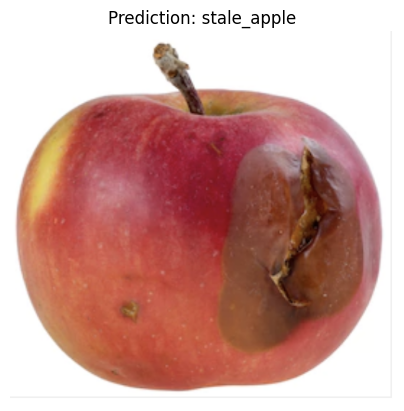

🍏 Predicted Label: stale_apple


In [ ]:
# Ensure all necessary installations are updated and correct
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Importing Required Libraries
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision.models import swin_t, Swin_T_Weights  # Swin Transformer
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive, files  # For Google Drive access and image upload

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')  # Mount Google Drive
drive_path = '/content/drive/MyDrive/ViT_Fruit_Classifier (1)/archive.zip'  # Update with your Drive dataset path
dataset_root = '/content/fruits'  # Extracted dataset folder path

# 2️⃣ Extract Dataset
if not os.path.exists(dataset_root):  # Extract dataset only if not already done
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_root)
    print("✅ Dataset extracted successfully!")

# Ensure correct dataset path
subfolders = [f.name for f in os.scandir(dataset_root) if f.is_dir()]
dataset_path = os.path.join(dataset_root, subfolders[0]) if len(subfolders) == 1 else dataset_root

print("✅ Using dataset path:", dataset_path)

# 3️⃣ Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 4️⃣ Load Dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("✅ Classes found:", dataset.classes)
print("✅ Train images:", len(train_dataset), "| Test images:", len(test_dataset))

# 5️⃣ Define Swin Transformer Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)  # Dynamically determine the number of classes

weights = Swin_T_Weights.IMAGENET1K_V1  # Pretrained weights for Swin Transformer
model = swin_t(weights=weights)
model.head = nn.Linear(model.head.in_features, num_classes)  # Modify the head for our dataset
model = model.to(device)

# 6️⃣ Define Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
scaler = GradScaler()  # Mixed precision training

# 7️⃣ Train Model
num_epochs = 20
print("\n🚀 Training Started...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

print("\n🎉 Training Complete!")

# 8️⃣ Save Model
model_path = "/content/swin_fruit_freshness_model.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at {model_path}")

# 9️⃣ Evaluate Model
model.eval()
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"\n📊 Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy:.2f}%")

# 🔟 Predict Fresh or Stale for a Single Image
def predict_fruit_freshness():
    print("📂 Upload an image for prediction:")
    uploaded = files.upload()

    if uploaded:
        for image_name in uploaded.keys():
            image_path = image_name
            image = Image.open(image_path).convert("RGB")
            transformed_image = transform(image).unsqueeze(0).to(device)

            # Make prediction
            with torch.no_grad():
                output = model(transformed_image)
                _, predicted_class = torch.max(output, 1)

            class_names = dataset.classes
            predicted_label = class_names[predicted_class.item()]

            # Display image
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"Prediction: {predicted_label}")
            plt.show()

            print(f"🍏 Predicted Label: {predicted_label}")

# 🔹 Call Prediction Function
predict_fruit_freshness()


📂 Upload an image for prediction:


Saving Screen Shot 2018-06-07 at 2.17.25 PM.png to Screen Shot 2018-06-07 at 2.17.25 PM.png


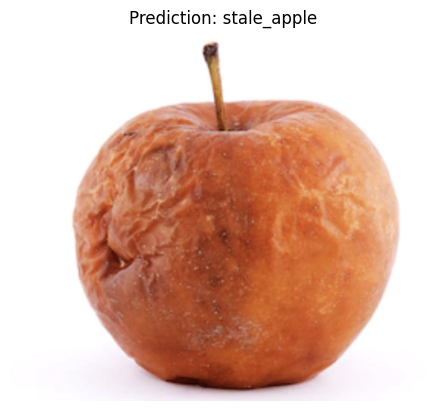

🍏 Predicted Label: stale_apple


In [ ]:
def predict_fruit_freshness():
    print("📂 Upload an image for prediction:")
    uploaded = files.upload()

    if uploaded:
        for image_name in uploaded.keys():
            image_path = image_name
            image = Image.open(image_path).convert("RGB")
            transformed_image = transform(image).unsqueeze(0).to(device)

            # Make prediction
            with torch.no_grad():
                output = model(transformed_image)
                _, predicted_class = torch.max(output, 1)

            class_names = dataset.classes
            predicted_label = class_names[predicted_class.item()]

            # Display image
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"Prediction: {predicted_label}")
            plt.show()

            print(f"🍏 Predicted Label: {predicted_label}")

# 🔹 Call Prediction Function
predict_fruit_freshness()


In [ ]:
# Save full model to .pt
torch.save(model, 'vit_model.pt')

# Save full model to .pkl
import pickle
with open('vit_model.pkl', 'wb') as f:
    pickle.dump(model, f)


In [ ]:
# Load from .pt (include architecture)
loaded_model_pt = torch.load('vit_model.pt', weights_only=False)
loaded_model_pt.eval()

# Load from .pkl
with open('vit_model.pkl', 'rb') as f:
    loaded_model_pkl = pickle.load(f)
loaded_model_pkl.eval()


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [ ]:
# Load from .pkl
with open(pkl_path, 'rb') as f:
    loaded_model_pkl = pickle.load(f)
loaded_model_pkl.eval()


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [ ]:
import torch
import pickle

# Replace this with your actual model
# Example: model = MyViTModel()

# Save paths
pt_path = 'vit_model.pt'
pkl_path = 'vit_model.pkl'

# Save model to .pt
torch.save(model, pt_path)

# Save model to .pkl
with open(pkl_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model saved to:\n- {pt_path}\n- {pkl_path}")


Model saved to:
- vit_model.pt
- vit_model.pkl


In [ ]:
import torch
import pickle
import shutil
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Replace this with your actual model
# Example: model = MyViTModel()

# Local save paths
pt_path = 'vit_model.pt'
pkl_path = 'vit_model.pkl'

# Save model to .pt
torch.save(model, pt_path)

# Save model to .pkl
with open(pkl_path, 'wb') as f:
    pickle.dump(model, f)

# Define Drive destination folder
drive_folder = '/content/drive/MyDrive/vit_model_files/'

# Create folder if it doesn't exist
import os
os.makedirs(drive_folder, exist_ok=True)

# Copy files to Google Drive
shutil.copy(pt_path, drive_folder + pt_path)
shutil.copy(pkl_path, drive_folder + pkl_path)

print(f"Model saved locally and to Google Drive at:\n- {drive_folder + pt_path}\n- {drive_folder + pkl_path}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved locally and to Google Drive at:
- /content/drive/MyDrive/vit_model_files/vit_model.pt
- /content/drive/MyDrive/vit_model_files/vit_model.pkl
